# Comparing UPs with Cohen's Kappa

Cohen's Kappa is a **statistical measure used to assess the agreement between two raters who are classifying items into a set of categories.** It's a more robust measure than simple percent agreement because **it corrects for the agreement that could occur by chance.** The kappa value ranges from \(-1\) to \(1\), where \(1\) indicates perfect agreement, \(0\) indicates agreement no better than chance, and negative values indicate disagreement worse than chance. 

In [ ]:
class Modality:
    SCREEN_VLM = "screen_vlm"
    SCREEN_OCR = "screen_ocr"
    AX = "accessibility"

## preparing UPs

In [7]:
user_profile_paths = {
    Modality.SCREEN_VLM: "output_data/screen_vlm_results/yulia_user_profile.md",
    Modality.SCREEN_OCR: "output_data/ocr_results/yulias_profile.md",
    Modality.AX: "output_data/ax_results/user_profile_ax__gpt-4o-mini.md"
}

In [9]:
def read_md_file(path: str) -> str:
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

In [11]:
user_profiles = {}
    
for modality, path in user_profile_paths.items():
    user_profiles[modality] = read_md_file(path)

In [12]:
user_profiles[Modality.AX]

'# User Profile\n\n## Basic Information\n- Name: Yulia\n- Platform: macOS\n- Occupation/Domain: Engaged in software development and AI-related project work\n- Language: Prefers English (United States) for interfaces\n- Collaboration: Participates in the MacPaw Slack workspace\n\n## Interests & Focus Areas\n- AI tools and local AI model exploration (e.g., LocalAIChat, Hugging Face models)\n- Python development and project configuration\n- Data/annotation collaboration in AI-focused channels\n- Cloud services usage (Google Cloud Platform)\n\n## Current Activities\n- Managing and coding in the “context-user-model” project (requirements.txt, setup.sh, Makefile)\n- Troubleshooting installation and file permissions for LocalAIChat; removing quarantine attributes; attempting to open the app\n- Configuring and troubleshooting pritunl.service via launchctl on macOS\n- Signing into and managing Google services (Calendar, Gmail, Google Cloud Platform)\n- Collaborating via Slack (e.g., ai-plus-ai-

## preparing Propositions

In [13]:
propositions_paths = {
    Modality.SCREEN_VLM: "output_data/screen_vlm_results/propositions_gpt-4o-mini.jsonl",
    Modality.SCREEN_OCR: "output_data/ocr_results/propositions_gpt-4o-mini.jsonl",
    Modality.AX: "output_data/ax_results/propositions_ax__gpt-4o-mini.jsonl"
}

In [14]:
def read_jsonl_lines(path: str) -> list[str]:
    """Read a JSONL file line by line and return a list of non-empty strings."""
    lines = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                lines.append(line)
    return lines

In [20]:
propositions = {}
    
for modality, path in propositions_paths.items():
    propositions[modality] = read_jsonl_lines(path)
    print(f"> {modality} has {len(propositions[modality])} propositions, avg length {sum([len(s) for s in propositions[modality]]) / len(propositions[modality]) }")

> screen_vlm has 20 propositions, avg length 2513.8
> screen_ocr has 20 propositions, avg length 2837.55
> accessibility has 6 propositions, avg length 2426.8333333333335


In [19]:
propositions[Modality.AX][0]

'{"batch_id": 0, "pair_indices": [0, 1, 3, 4, 5], "propositions": [{"reasoning": "Yulia is actively managing and configuring her project files, which include \'setup.sh\', \'requirements.txt\', and \'README.md\', as seen in her navigation through the Project Tool Window. These file interactions suggest she is likely involved in setting up or maintaining a development project.", "proposition": "Yulia is engaged in project management and configuration for a software development project.", "confidence": 8, "decay": 7}, {"reasoning": "The presence of the \'AI Assistant\' button in the Right Toolbar indicates that Yulia is using or has the potential to leverage AI tools to assist with her tasks, suggesting a preference for advanced assistance in her workflows.", "proposition": "Yulia is utilizing AI tools to aid her tasks and improve her workflow.", "confidence": 7, "decay": 6}, {"reasoning": "Yulia\'s repeated attempts to unzip \'LocalAIChat.app.zip\' and the issues she encounters with exe

## Comparing

In [22]:
import numpy as np
from collections import Counter

In [23]:
def cohen_kappa(rater1, rater2):
    """Compute Cohen's Kappa between two raters."""
    assert len(rater1) == len(rater2), "Raters must have the same number of items."
    labels = np.unique(rater1 + rater2)
    
    n = len(rater1)
    observed_agreement = np.sum(np.array(rater1) == np.array(rater2)) / n
    
    # Expected agreement
    p_r1 = Counter(rater1)
    p_r2 = Counter(rater2)
    expected_agreement = sum((p_r1[l] / n) * (p_r2[l] / n) for l in labels)
    
    kappa = (observed_agreement - expected_agreement) / (1 - expected_agreement)
    return kappa

In [92]:
def gwet_ac1(rater1, rater2):
    """Compute Gwet’s AC1 between two raters."""
    assert len(rater1) == len(rater2), "Raters must have the same number of items."
    rater1, rater2 = list(rater1), list(rater2)
    labels = np.unique(rater1 + rater2)

    n = len(rater1)
    observed_agreement = np.sum(np.array(rater1) == np.array(rater2)) / n

    # category proportions across both raters
    p = {label: (rater1.count(label) + rater2.count(label)) / (2 * n) for label in labels}

    # expected chance agreement per Gwet (2008)
    Pe = sum(2 * p_l * (1 - p_l) for p_l in p.values()) / 2

    # Gwet's AC1 formula
    ac1 = (observed_agreement - Pe) / (1 - Pe)
    return ac1


In [93]:
# Example usage
rater1 = ['A', 'A', 'B', 'B', 'C', 'C', 'B']
rater2 = ['A', 'A', 'B', 'B', 'C', 'C', 'B']

print("Cohen’s Kappa:", cohen_kappa(rater1, rater2))
print("Gwet’s AC1:", gwet_ac1(rater1, rater2))

Cohen’s Kappa: 1.0
Gwet’s AC1: 1.0


1. Cohen’s Kappa adjusts observed agreement by expected agreement under chance.
2. Gwet’s AC1 corrects for the paradox where Kappa becomes low when raters agree often (prevalence bias).

In [31]:
# from evaluation pipeline

import json
from typing import List, Dict, Any
from openai import OpenAI
import csv
import os
from dotenv import load_dotenv

load_dotenv()

def check_propositions_against_profile(
    profile_text: str,
    propositions: List[str],
    model: str = "gpt-4o-mini",
    api_key: str | None = None,
    batch_size: int = 10,   # process N propositions at a time
) -> List[Dict[str, Any]]:
    """
    Returns a list of dicts: { 'proposition': str, 'supported': bool}
    'supported' is True only if the profile explicitly or implicitly substantiates the claim.
    """
    client = OpenAI(api_key=api_key)
    all_results: List[Dict[str, Any]] = []

    system_msg = (
        "You are a careful fact-checker. "
        "Given a short user profile and a list of propositions, decide for each proposition "
        "whether the profile SUPPORTS it (True) or NOT SUPPORTED (False).\n\n"
        "Definition of SUPPORTS:\n"
        "- True if the profile explicitly states the proposition.\n"
        "- True if the profile clearly and strongly implies the proposition.\n"
        "- True if the profile describes a GENERAL CATEGORY that covers the proposition "
        "  (e.g., 'works in software development' covers 'debugging Python scripts').\n"
        "- False if the profile does not mention it, only vaguely hints at it, or contradicts it.\n\n"
        "Be strict: do not guess beyond what is explicit, clearly implied, or included in a general category."
    )

    # process in batches
    for i in range(0, len(propositions), batch_size):
        batch = propositions[i : i + batch_size]

        user_msg = f"""
        USER PROFILE
        ---
        {profile_text.strip()}

        PROPOSITIONS
        ---
        {json.dumps(batch, ensure_ascii=False, indent=2)}

        OUTPUT FORMAT
        ---
        Return a JSON object with this exact shape:
        {{
        "results": [
            {{"proposition": "...", "supported": true/false}}
        ]
        }}

        RULES
        - "supported": true only if the profile explicitly states or strongly implies the proposition.
        - If the profile doesn't mention it or it's speculative → supported = false.
        """

        resp = client.chat.completions.create(
            model=model,
            temperature=0,
            response_format={
                "type": "json_schema",
                "json_schema": {
                    "name": "propositions_schema",
                    "schema": {
                        "type": "object",
                        "properties": {
                            "results": {
                                "type": "array",
                                "items": {
                                    "type": "object",
                                    "properties": {
                                        "proposition": {"type": "string"},
                                        "supported": {"type": "boolean"}
                                    },
                                    "required": ["proposition", "supported"]
                                }
                            }
                        },
                        "required": ["results"]
                    }
                },
            },
            messages=[
                {"role": "system", "content": system_msg},
                {"role": "user", "content": user_msg},
            ],
        )

        content = resp.choices[0].message.content

        try:
            data = json.loads(content)
        except json.JSONDecodeError:
            print("JSON decoding failed, raw content:\n", content[:100])
            fixed = content.strip()
            fixed = fixed.replace("\n", " ")  # flatten
            fixed = fixed.replace(",}", "}")  # remove trailing commas
            fixed = fixed.replace(",]", "]")  # remove trailing commas
            data = json.loads(fixed)

        all_results.extend(data["results"])

    return all_results

In [33]:
merged_propositions = []

for _, mpropositions in propositions.items():
    merged_propositions += mpropositions

len(merged_propositions)

46

In [34]:
merged_propositions[0]

'{"batch_id": 0, "pair_indices": [0, 1, 2, 3, 4], "propositions": [{"reasoning": "Yulia is engaged in audio work, evident from her interaction with the \'Recording Control\' interface where she manages recording settings for past sessions, indicated by references to options labeled \'Start\', \'Stop\', and \'Pause\'. This suggests a clear focus on audio management or production tasks.", "proposition": "Yulia is actively working on audio recording or management tasks.", "confidence": 8, "decay": 5}, {"reasoning": "The snippets from the \'Code Editor\' show engagement with audio configuration, particularly regarding sound output settings. Yulia is adjusting options like \'Play sound through\' and \'Output device\', suggesting her focus on technical aspects of sound for a specific project.", "proposition": "Yulia is involved in software development, particularly configuring audio behavior in her projects.", "confidence": 7, "decay": 6}, {"reasoning": "Yulia\'s environment includes her nav

In [50]:
import json

props = []
for prop in merged_propositions:
    props += json.loads(prop)["propositions"]

len(props), props[0]

(231,
 {'reasoning': "Yulia is engaged in audio work, evident from her interaction with the 'Recording Control' interface where she manages recording settings for past sessions, indicated by references to options labeled 'Start', 'Stop', and 'Pause'. This suggests a clear focus on audio management or production tasks.",
  'proposition': 'Yulia is actively working on audio recording or management tasks.',
  'confidence': 8,
  'decay': 5})

In [51]:
comparison = {}

for modality, uprofile in user_profiles.items():
    comparison[modality] = check_propositions_against_profile(
        profile_text=uprofile,
        propositions=props,
    )
    print(f"Finished {modality} comparison with {len(props)} propositions | got {len(comparison[modality])} labeled ones")

Finished screen_vlm comparison with 231 propositions | got 231 labeled ones
Finished screen_ocr comparison with 231 propositions | got 231 labeled ones
Finished accessibility comparison with 231 propositions | got 231 labeled ones


In [52]:
comparison[Modality.AX][0]

{'proposition': 'Yulia is actively working on audio recording or management tasks.',
 'supported': False}

In [95]:
labels = {}

for modality, labeled_propositions in comparison.items():
    labels[modality] = [lp['supported'] for lp in labeled_propositions]    
    print(f"{modality} has {len(labeled_propositions)} propositions")

screen_vlm has 231 propositions
screen_ocr has 231 propositions
accessibility has 231 propositions


In [96]:
print(labels[Modality.AX][:10])

[False, False, True, False, False, True, False, True, True, False]


In [97]:
aggrement_kappa = {}
aggrement_qwet = {}

for modality1, mlabels1 in labels.items():
    aggrement_kappa[modality1] = {}
    aggrement_qwet[modality1] = {}
    for modality2, mlabels2 in labels.items():
        aggrement_kappa[modality1][modality2] = cohen_kappa(mlabels1, mlabels2)
        aggrement_qwet[modality1][modality2] = gwet_ac1(mlabels1, mlabels2)

In [98]:
aggrement_kappa, aggrement_qwet

({'screen_vlm': {'screen_vlm': np.float64(1.0),
   'screen_ocr': np.float64(0.6032477164493716),
   'accessibility': np.float64(0.5112145577655522)},
  'screen_ocr': {'screen_vlm': np.float64(0.6032477164493716),
   'screen_ocr': np.float64(1.0),
   'accessibility': np.float64(0.6109353818346136)},
  'accessibility': {'screen_vlm': np.float64(0.5112145577655522),
   'screen_ocr': np.float64(0.6109353818346136),
   'accessibility': np.float64(1.0)}},
 {'screen_vlm': {'screen_vlm': np.float64(1.0),
   'screen_ocr': np.float64(0.6394849785407726),
   'accessibility': np.float64(0.5376721675369807)},
  'screen_ocr': {'screen_vlm': np.float64(0.6394849785407726),
   'screen_ocr': np.float64(1.0),
   'accessibility': np.float64(0.6748768472906405)},
  'accessibility': {'screen_vlm': np.float64(0.5376721675369807),
   'screen_ocr': np.float64(0.6748768472906405),
   'accessibility': np.float64(1.0)}})

In [ ]:
!pip install sympy seaborn matlotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


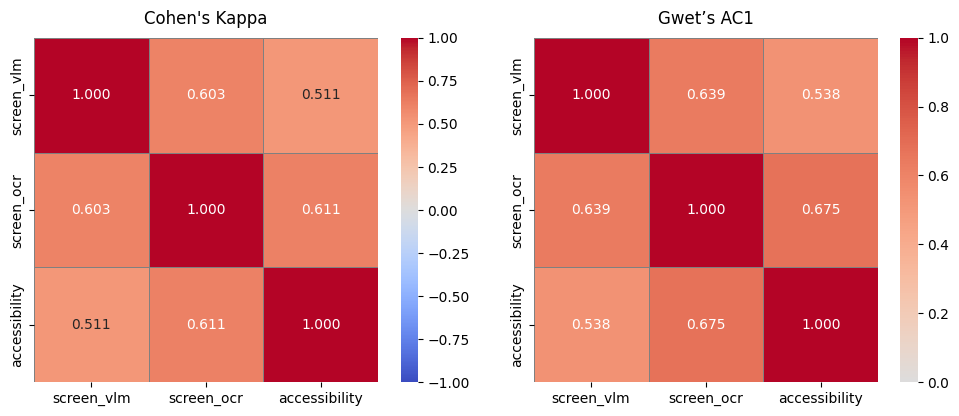

In [104]:
import sympy as sp
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to sympy Matrix and then numpy array
labels = list(aggrement_kappa.keys())

matrix_kappa = sp.Matrix([[aggrement_kappa[r1][r2] for r2 in labels] for r1 in labels])
matrix_gwet  = sp.Matrix([[aggrement_qwet[r1][r2]  for r2 in labels] for r1 in labels])

arr_kappa = np.array(matrix_kappa, dtype=float)
arr_gwet  = np.array(matrix_gwet, dtype=float)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, arr, title, (min, max) in zip(
    axes,
    [arr_kappa, arr_gwet],
    ["Cohen's Kappa", "Gwet’s AC1"],
    [(-1, 1), (0, 1)]
):
    sns.heatmap(
        arr,
        annot=True,
        fmt=".3f",
        cmap="coolwarm",
        center=0,
        xticklabels=labels,
        yticklabels=labels,
        vmin=min,
        vmax=max,
        square=True,
        linewidths=0.5,
        linecolor='gray',
        ax=ax
    )
    ax.set_title(title, fontsize=12, pad=10)

plt.tight_layout()
plt.show()